In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("network_traffic.csv")

In [3]:
df.head()

,time,source_ip_int,destination_ip_int,source_port,destination_port,protocol,duration,packet_count,bytes_sent,bytes_received,label,bytes_per_packet
0,2025-04-07 03:25:53,3232281727,167792955,32237,995,0,2.910802,74,9200,4879,0,124.324324
1,2025-04-07 08:38:03,3232236596,167774143,15995,995,0,4.661168,33,4015,1848,0,121.666667
2,2025-04-07 04:37:03,3232276946,167832337,65426,80,0,1.802558,23,2572,3190,0,111.826087
3,2025-04-07 01:30:53,3232270434,167796473,16433,993,0,4.126773,92,2993,3000,0,32.532609
4,2025-04-06 20:58:03,3232267105,167776023,27110,143,2,1.949097,43,4257,6826,0,99.000000


In [4]:
df.tail()

,time,source_ip_int,destination_ip_int,source_port,destination_port,protocol,duration,packet_count,bytes_sent,bytes_received,label,bytes_per_packet
10000,2025-04-06 20:40:18,3232250619,167783555,59711,64660,5,9.643456,78,17193,11333,1,220.423077
10001,2025-04-07 05:20:03,3232295215,167799884,26804,995,1,1.425016,91,240,981,0,2.637363
10002,2025-04-07 05:24:53,3232292523,167822026,63303,23,1,2.121701,43,4877,7670,0,113.418605
10003,2025-04-07 17:11:53,3232252147,167774716,31382,993,1,1.787258,28,6632,366,0,236.857143
10004,2025-04-07 15:34:53,3232293831,167788159,54016,443,0,3.458926,45,3109,9827,0,69.088889


In [5]:
df.isnull().sum()

,0
time,0
source_ip_int,0
destination_ip_int,0
source_port,0
destination_port,0
protocol,0
duration,0
packet_count,0
bytes_sent,0
bytes_received,0


In [6]:
df.shape

(10005, 12)

In [7]:
df.describe()

,source_ip_int,destination_ip_int,source_port,destination_port,protocol,duration,packet_count,bytes_sent,bytes_received,label,bytes_per_packet
count,1.000500e+04,1.000500e+04,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.00000,10005.000000
mean,3.231715e+09,1.693629e+08,33548.602599,5321.814393,0.461769,3.803535,275.166217,28982.593103,6791.777811,0.20040,227.817587
std,3.938386e+07,6.970124e+07,18731.288377,14808.430925,0.908808,7.399396,1173.655594,119121.191880,4766.473452,0.40032,531.940607
min,1.684301e+08,1.677724e+08,1031.000000,22.000000,0.000000,0.010000,1.000000,40.000000,40.000000,0.00000,1.105263
25%,3.232252e+09,1.677884e+08,17318.000000,25.000000,0.000000,1.067467,27.000000,2225.000000,2330.000000,0.00000,42.000000
50%,3.232268e+09,1.678047e+08,33652.000000,110.000000,0.000000,2.432208,54.000000,5311.000000,6407.000000,0.00000,91.179104
75%,3.232285e+09,1.678212e+08,49910.000000,993.000000,1.000000,3.931768,82.000000,8308.000000,10850.000000,0.00000,177.080000
max,3.232301e+09,3.405804e+09,65528.000000,65427.000000,5.000000,59.770563,15000.000000,999323.000000,19925.000000,1.00000,8440.542373


<Axes: xlabel='protocol', ylabel='count'>

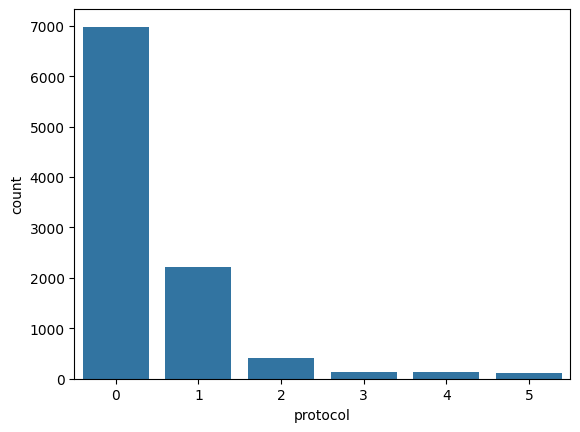

In [9]:
sns.countplot(x='protocol', data=df)

<Axes: xlabel='packet_count', ylabel='Count'>

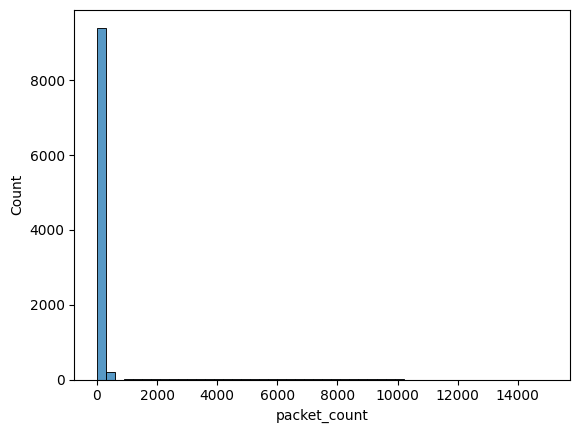

In [11]:
sns.histplot(df['packet_count'], bins=50)

<Axes: xlabel='duration', ylabel='bytes_received'>

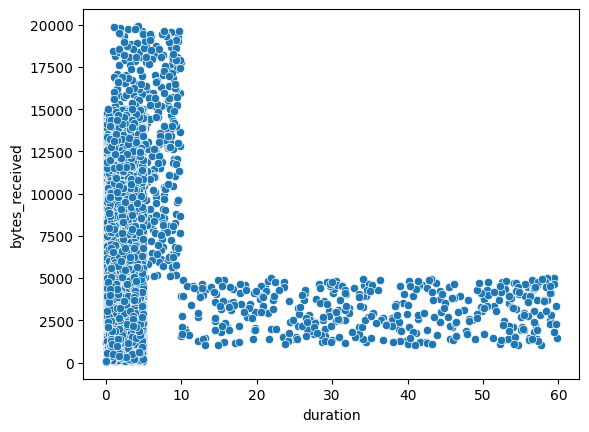

In [14]:
sns.scatterplot(x='duration', y='bytes_received', data=df)


<Axes: >

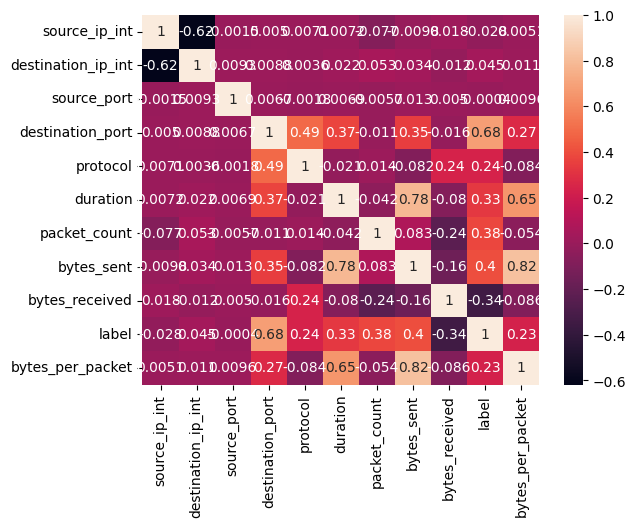

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['protocol'] = le.fit_transform(df['protocol'])

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['duration','packet_count','bytes_sent','source_port','destination_port','protocol']]
y = df['bytes_received']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))

R2 Score: 0.12963566848507801
MSE: 19828898.182934556


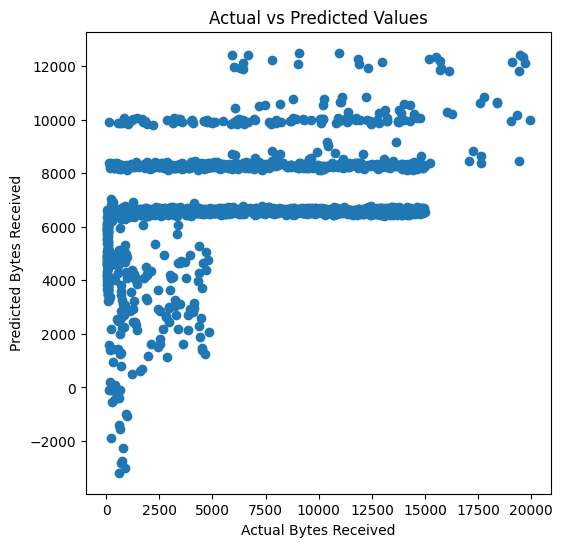

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Bytes Received")
plt.ylabel("Predicted Bytes Received")
plt.title("Actual vs Predicted Values")

plt.show()

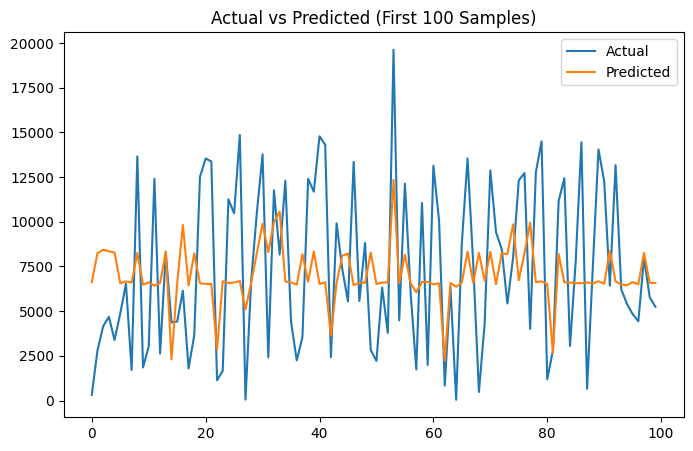

In [19]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted (First 100 Samples)")

plt.show()